<a href="https://colab.research.google.com/github/Thiashopy04/PROSES-MINING/blob/main/TUGAS_BESAR_UAS_PROSES_MINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pm4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter
import pm4py

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Incident_Management_CSV.csv to Incident_Management_CSV (1).csv


In [ ]:
df = pd.read_csv("Incident_Management_CSV.csv", sep=";")
df.head()


,Case ID,Variant,Priority,Reporter,Timestamp,Event,Issue Type,Resolver,Report Channel,Short Description,Customer Satisfaction
0,INC0001,Variant 4,Medium,Alice,17/11/2023 11:17,Ticket created,Performance Issue,NaN,Website,Application crash,3
1,INC0001,Variant 4,Medium,Alice,17/11/2023 13:30,Ticket assigned to level 1 support,Performance Issue,Sam,Website,Application crash,3
2,INC0001,Variant 4,Medium,Alice,17/11/2023 14:06,WIP - level 1 support,Performance Issue,Sam,Website,Application crash,3
3,INC0001,Variant 4,Medium,Alice,17/11/2023 16:52,Level 1 escalates to level 2 support,Performance Issue,Michael,Website,Application crash,3
4,INC0001,Variant 4,Medium,Alice,17/11/2023 18:07,WIP - level 2 support,Performance Issue,Emma,Website,Application crash,3


In [ ]:
df.columns


Index(['Case ID', 'Variant', 'Priority', 'Reporter', 'Timestamp', 'Event',
       'Issue Type', 'Resolver', 'Report Channel', 'Short Description',
       'Customer Satisfaction'],
      dtype='object')

In [ ]:
df = df.rename(columns={
    "Case ID": "case:concept:name",
    "Event": "concept:name",
    "Timestamp": "time:timestamp",
    "Resolver": "org:resource"
})


In [ ]:
df.columns


Index(['case:concept:name', 'Variant', 'Priority', 'Reporter',
       'time:timestamp', 'concept:name', 'Issue Type', 'org:resource',
       'Report Channel', 'Short Description', 'Customer Satisfaction'],
      dtype='object')

In [ ]:
df["time:timestamp"] = pd.to_datetime(
    df["time:timestamp"],
    dayfirst=True,
    errors="coerce"
)


In [ ]:
from pm4py.objects.conversion.log import converter as log_converter

event_log = log_converter.apply(
    df,
    variant=log_converter.Variants.TO_EVENT_LOG
)


In [ ]:
len(event_log)


31588

# **EXPLORATORY PROCESS ANALYSIS**

1️⃣ Jumlah Kasus (Number of Cases)

In [ ]:
num_cases = df["case:concept:name"].nunique()
num_cases


31588

2️⃣ Jumlah Aktivitas (Number of Activities)

In [ ]:
num_activities = df["concept:name"].nunique()
num_activities


18

3️⃣ Jumlah Event (Number of Events)

In [ ]:
num_events = len(df)
num_events


242901

4️⃣ Rata-rata Durasi Proses (Average Case Duration)

In [ ]:
case_duration = (
    df.groupby("case:concept:name")["time:timestamp"]
      .agg(["min", "max"])
)

case_duration["duration"] = (
    case_duration["max"] - case_duration["min"]
)

average_duration = case_duration["duration"].mean()
average_duration


Timedelta('0 days 15:01:54.390907939')

5️⃣ Aktivitas Paling Sering Terjadi

In [ ]:
activity_frequency = df["concept:name"].value_counts()
activity_frequency.head()


,count
concept:name,
Ticket closed,32776
WIP - level 1 support,32223
Ticket created,31588
Ticket assigned to level 1 support,31250
Customer feedback received,30338


6️⃣ Aktivitas Awal & Akhir Dominan

🔹 Aktivitas Awal

In [ ]:
start_activities = (
    df.sort_values("time:timestamp")
      .groupby("case:concept:name")
      .first()["concept:name"]
      .value_counts()
)

start_activities


,count
concept:name,
Ticket created,31588


🔹 Aktivitas Akhir

In [ ]:
end_activities = (
    df.sort_values("time:timestamp")
      .groupby("case:concept:name")
      .last()["concept:name"]
      .value_counts()
)

end_activities


,count
concept:name,
Ticket closed,31588


📊**VISUALISASI**

1️⃣ Frequency of Activities

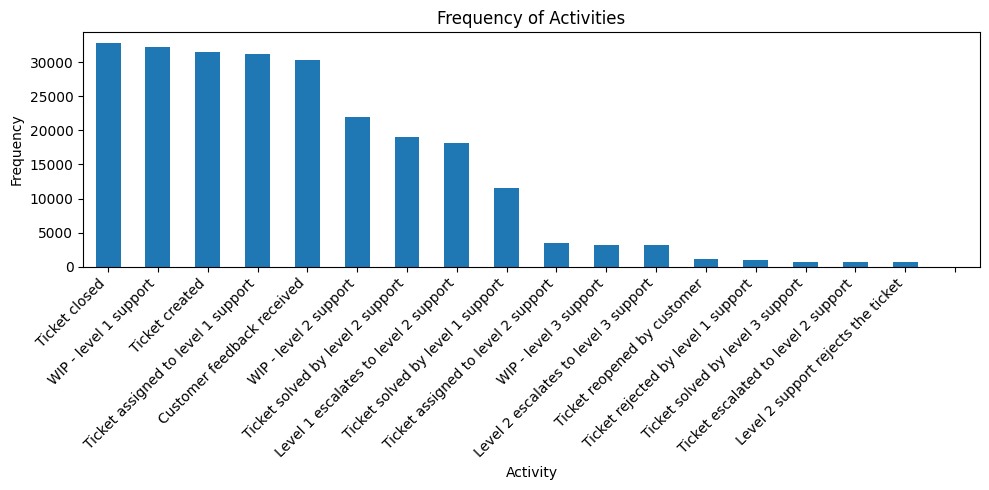

In [ ]:
plt.figure(figsize=(10,5))
activity_frequency.plot(kind="bar")
plt.title("Frequency of Activities")
plt.xlabel("Activity")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


2️⃣ Distribution of Case Duration

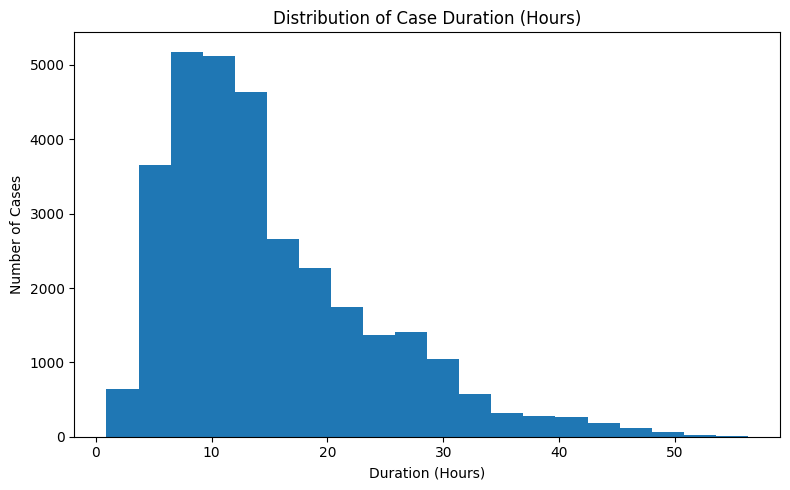

In [ ]:
case_duration_hours = case_duration["duration"].dt.total_seconds() / 3600

plt.figure(figsize=(8,5))
plt.hist(case_duration_hours, bins=20)
plt.title("Distribution of Case Duration (Hours)")
plt.xlabel("Duration (Hours)")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()


# **PROCESS DISCOVERY**

1️⃣ Membangun Model Proses (Inductive Miner)

In [ ]:
process_tree = pm4py.discover_process_tree_inductive(event_log)
process_tree


->( 'Ticket created', +( X( tau, *( 'Ticket assigned to level 1 support', tau ) ), ->( X( tau, ' ', 'Ticket rejected by level 1 support' ), +( *( 'Ticket closed', tau ), X( tau, ->( +( X( tau, *( 'Customer feedback received', tau ) ), ->( +( X( tau, *( 'WIP - level 1 support', tau ) ), X( tau, ->( X( tau, 'Ticket escalated to level 2 support', 'Level 1 escalates to level 2 support' ), X( tau, +( *( 'WIP - level 2 support', tau ), X( tau, ->( X( tau, +( X( tau, *( 'WIP - level 3 support', tau ) ), X( tau, *( 'Ticket assigned to level 2 support', tau ) ), X( tau, *( 'Level 2 escalates to level 3 support', tau ) ) ) ), X( tau, *( 'Ticket solved by level 2 support', 'Ticket reopened by customer' ) ) ) ) ) ) ) ) ), X( tau, 'Ticket solved by level 1 support', 'Ticket solved by level 3 support' ) ) ), X( tau, 'Level 2 support rejects the ticket' ) ) ) ) ) ) )

2️⃣ Konversi ke Petri Net

In [ ]:
net, initial_marking, final_marking = pm4py.convert_to_petri_net(process_tree)


3️⃣ Visualisasi Petri Net

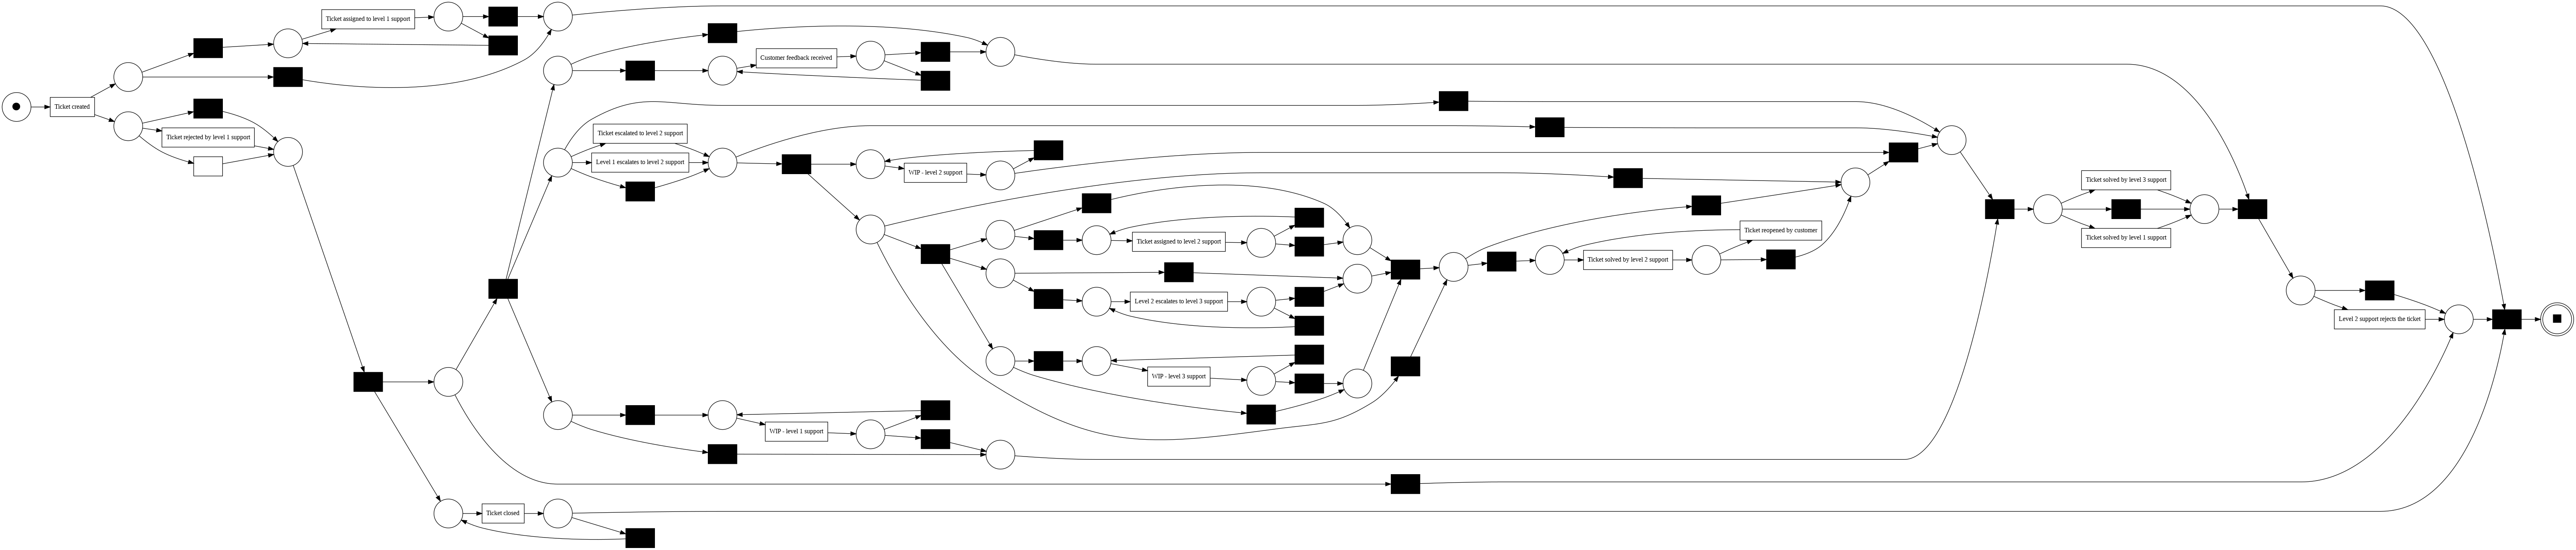

In [ ]:
pm4py.view_petri_net(net, initial_marking, final_marking)


4️⃣ Process Map berbasis Frekuensi

In [ ]:
pm4py.view_process_map(event_log)


AttributeError: module 'pm4py' has no attribute 'view_process_map'

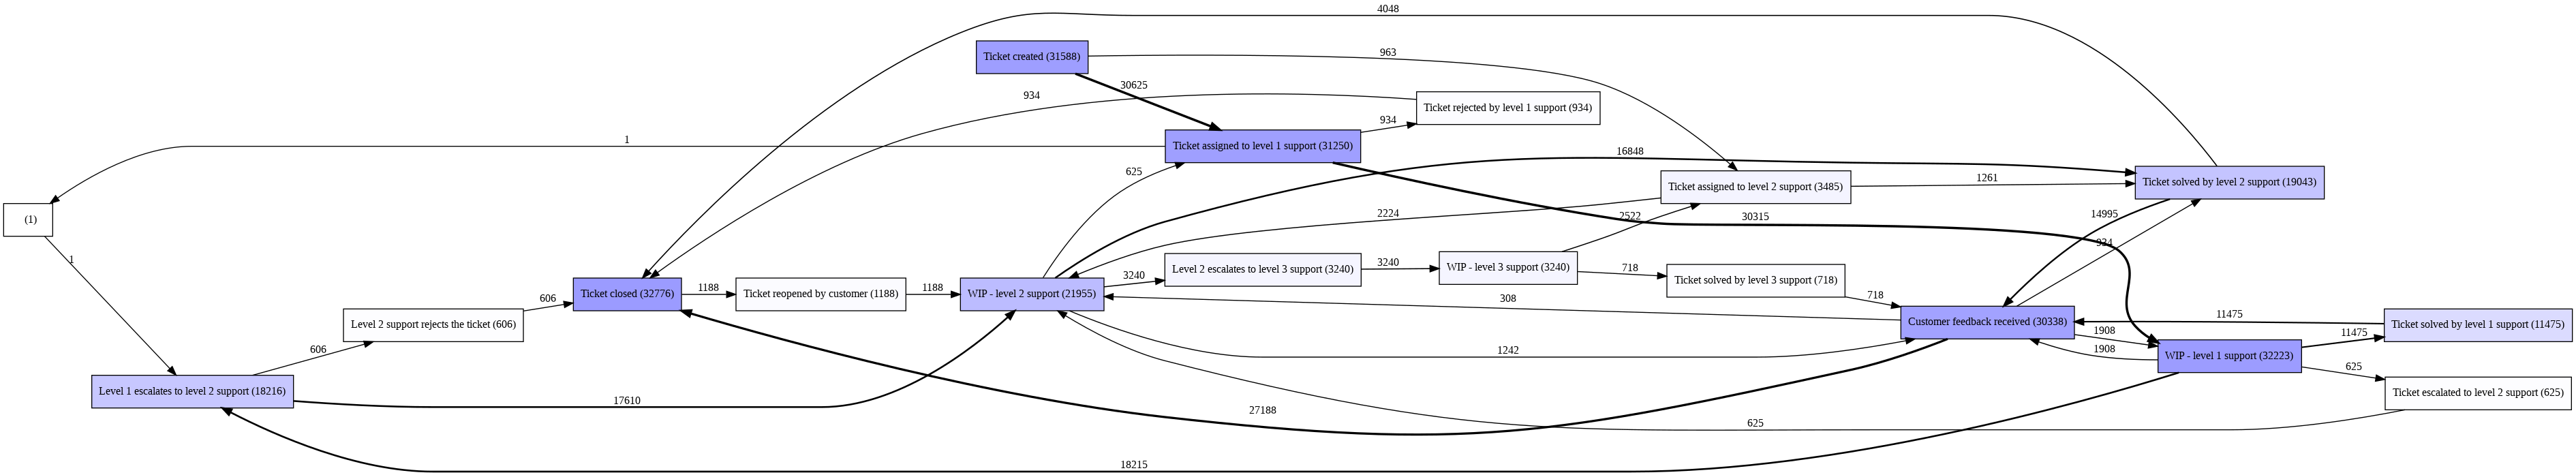

In [ ]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualization

dfg = dfg_discovery.apply(event_log)

gviz = dfg_visualization.apply(
    dfg,
    log=event_log,
    variant=dfg_visualization.Variants.FREQUENCY
)

dfg_visualization.view(gviz)


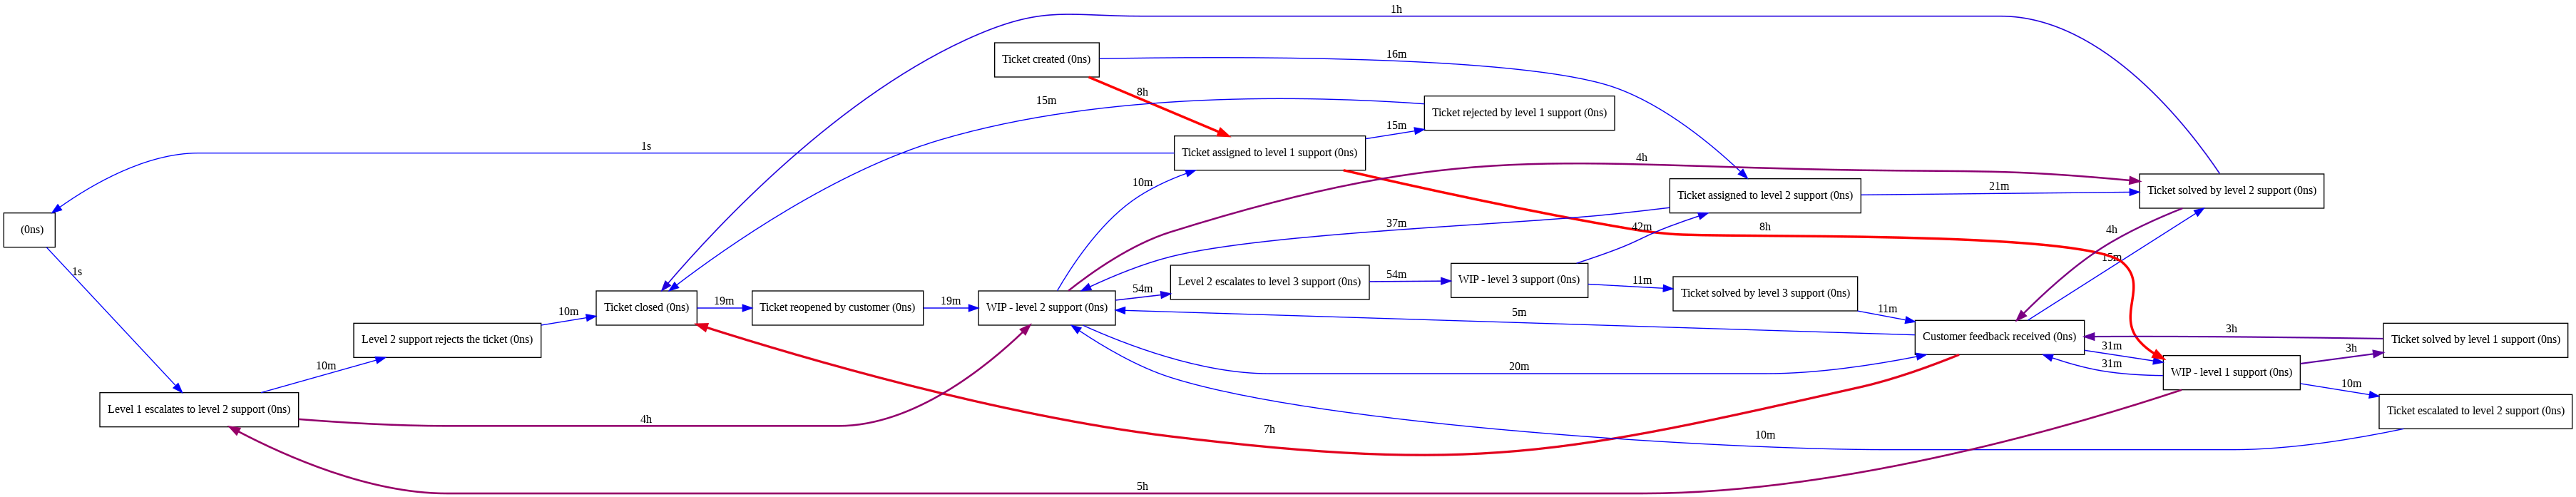

In [ ]:
gviz_perf = dfg_visualization.apply(
    dfg,
    log=event_log,
    variant=dfg_visualization.Variants.PERFORMANCE
)

dfg_visualization.view(gviz_perf)


# **CONFORMANCE CHECKING**

1️⃣ Persiapan Model & Log

In [ ]:
# net, initial_marking, final_marking
# event_log


2️⃣ Fitness (Token-Based Replay)

🔧 Hitung Fitness

In [ ]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

replay_result = token_replay.apply(
    event_log,
    net,
    initial_marking,
    final_marking
)

fitness = pm4py.fitness_token_based_replay(
    event_log,
    net,
    initial_marking,
    final_marking
)

fitness


replaying log with TBR, completed traces ::   0%|          | 0/14 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/14 [00:00<?, ?it/s]

{'perc_fit_traces': 100.0,
 'average_trace_fitness': 1.0,
 'log_fitness': 1.0,
 'percentage_of_fitting_traces': 100.0}

✍️ Interpretasi Fitness

Fitness mengukur sejauh mana event log dapat direproduksi oleh model proses. Nilai fitness mendekati 1 menunjukkan bahwa sebagian besar perilaku aktual dapat dijelaskan oleh model.

3️⃣ Precision

In [ ]:
precision = pm4py.precision_token_based_replay(
    event_log,
    net,
    initial_marking,
    final_marking
)

precision


replaying log with TBR, completed traces ::   0%|          | 0/53 [00:00<?, ?it/s]

0.20940191957589227

✍️ Interpretasi:

Precision menunjukkan tingkat pembatasan model terhadap perilaku yang tidak terdapat dalam event log. Nilai tinggi menandakan model tidak terlalu permisif.

4️⃣ Generalization

In [ ]:
generalization = pm4py.generalization_tbr(
    event_log,
    net,
    initial_marking,
    final_marking
)

generalization


replaying log with TBR, completed traces ::   0%|          | 0/14 [00:00<?, ?it/s]

0.9666271828428677

✍️ Interpretasi:

Generalization menggambarkan kemampuan model untuk merepresentasikan variasi proses yang mungkin terjadi di luar data yang diamati.

5️⃣ Simplicity

In [ ]:
simplicity = pm4py.simplicity_petri_net(
    net,
    initial_marking,
    final_marking
)
simplicity


0.6179775280898876

INTERPRETASI


Simplicity mengukur tingkat kesederhanaan model proses. Model dengan nilai simplicity yang tinggi menunjukkan struktur yang tidak terlalu kompleks sehingga lebih mudah dipahami dan dianalisis.

6️⃣ Ringkasan Hasil Conformance

In [ ]:
conformance_summary = {
    "Fitness": fitness,
    "Precision": precision,
    "Generalization": generalization,
    "Simplicity": simplicity
}

conformance_summary


{'Fitness': {'perc_fit_traces': 100.0,
  'average_trace_fitness': 1.0,
  'log_fitness': 1.0,
  'percentage_of_fitting_traces': 100.0},
 'Precision': 0.20940191957589227,
 'Generalization': 0.9666271828428677,
 'Simplicity': 0.6179775280898876}

# **BOTTLENECK ANALYSIS**

1️⃣ Durasi Aktivitas (Activity Duration)

In [ ]:
df_sorted = df.sort_values(
    ["case:concept:name", "time:timestamp"]
)

df_sorted["next_timestamp"] = df_sorted.groupby(
    "case:concept:name"
)["time:timestamp"].shift(-1)

df_sorted["activity_duration"] = (
    df_sorted["next_timestamp"] - df_sorted["time:timestamp"]
)

activity_duration = (
    df_sorted.groupby("concept:name")["activity_duration"]
    .mean()
    .dropna()
)

activity_duration


,activity_duration
concept:name,
,0 days 01:51:00
Customer feedback received,0 days 01:01:27.506097962
Level 1 escalates to level 2 support,0 days 01:01:39.621212121
Level 2 escalates to level 3 support,0 days 01:03:04.425925925
Level 2 support rejects the ticket,0 days 01:01:29.009900990
Ticket assigned to level 1 support,0 days 01:01:35.116800
Ticket assigned to level 2 support,0 days 01:02:27.753228120
Ticket closed,0 days 01:02:48.636363636
Ticket created,0 days 03:53:13.203115107


✍️ Interpretasi:

Aktivitas dengan durasi rata-rata tertinggi berpotensi menjadi bottleneck utama.

2️⃣ Aktivitas dengan Frekuensi Tinggi & Durasi Lama

In [ ]:
activity_summary = pd.DataFrame({
    "Frequency": df["concept:name"].value_counts(),
    "Avg Duration": activity_duration
})

activity_summary.sort_values(
    by="Avg Duration",
    ascending=False
).head()


,Frequency,Avg Duration
concept:name,,
WIP - level 1 support,32223,0 days 04:14:17.823293920
WIP - level 2 support,21955,0 days 03:56:23.816898200
Ticket created,31588,0 days 03:53:13.203115107
,1,0 days 01:51:00
Ticket escalated to level 2 support,625,0 days 01:04:52.704000


✍️ Interpretasi:

Aktivitas yang sering muncul namun memiliki durasi lama berkontribusi signifikan terhadap keterlambatan proses.

3️⃣ Jalur Proses Paling Lambat (Slowest Path – DFG Performance)

In [ ]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery

dfg_perf = dfg_discovery.apply(
    event_log,
    variant=dfg_discovery.Variants.PERFORMANCE
)

dfg_perf


Counter({('Ticket created',
          'Ticket assigned to level 1 support'): 13982.979918367348,
         ('Ticket assigned to level 1 support',
          'WIP - level 1 support'): 3696.7144977733797,
         ('WIP - level 1 support',
          'Level 1 escalates to level 2 support'): 15239.785890749383,
         ('Level 1 escalates to level 2 support',
          'WIP - level 2 support'): 3701.93867120954,
         ('WIP - level 2 support',
          'Ticket solved by level 2 support'): 14128.821225071226,
         ('Ticket solved by level 2 support',
          'Ticket closed'): 3772.070158102767,
         ('Ticket solved by level 2 support',
          'Customer feedback received'): 3661.6325441813938,
         ('Customer feedback received', 'Ticket closed'): 3682.6908930410477,
         ('WIP - level 1 support',
          'Ticket escalated to level 2 support'): 15710.112,
         ('Ticket escalated to level 2 support',
          'WIP - level 2 support'): 3892.704,
         ('WIP - l

4️⃣ Visualisasi Performance Map

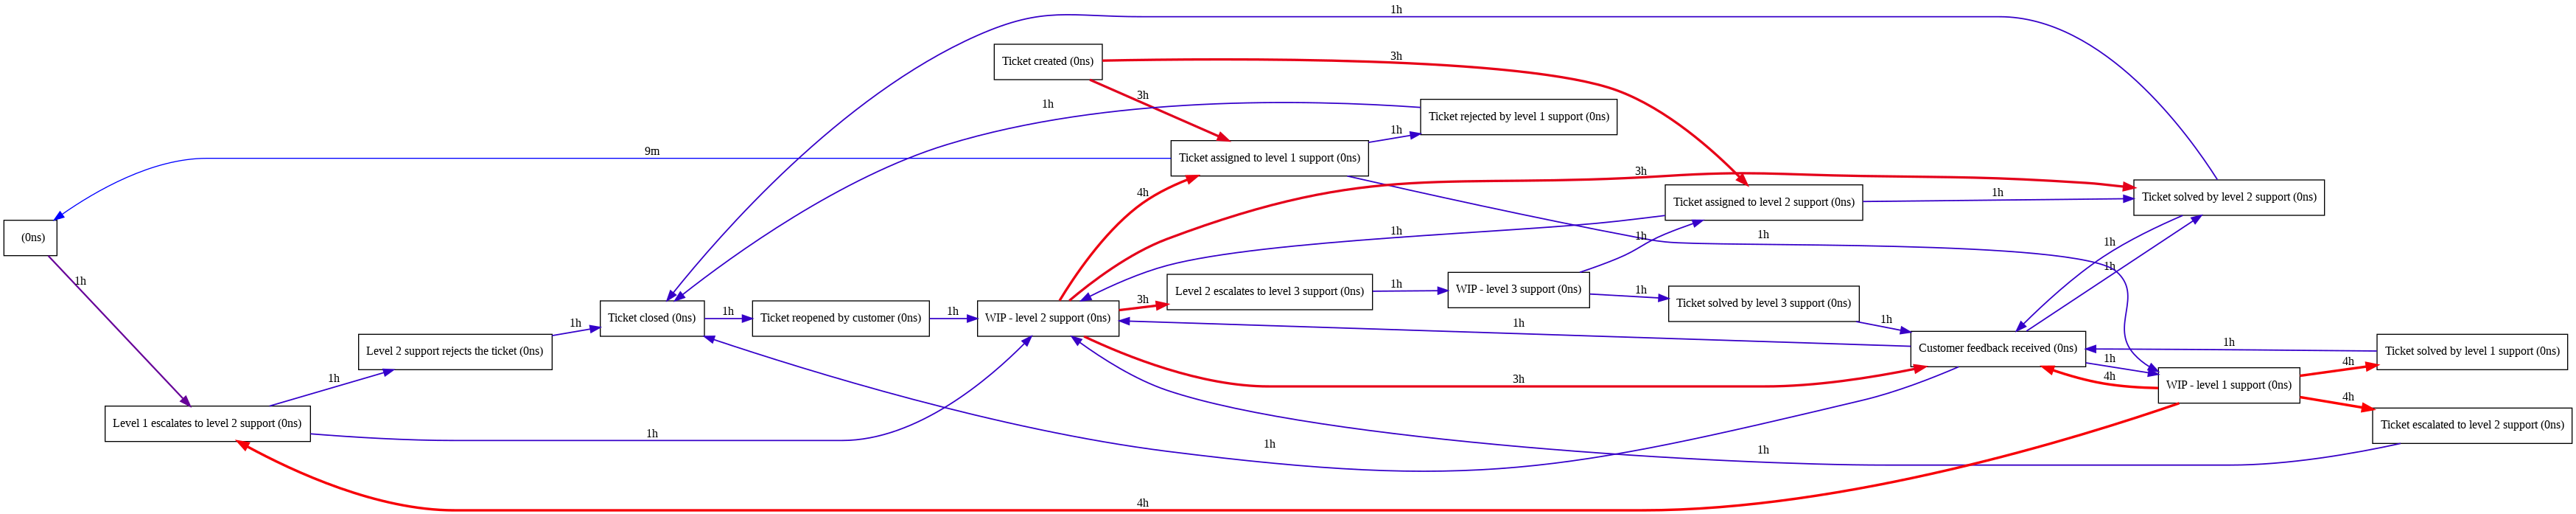

In [ ]:
from pm4py.visualization.dfg import visualizer as dfg_visualization

gviz_perf = dfg_visualization.apply(
    dfg_perf,
    log=event_log,
    variant=dfg_visualization.Variants.PERFORMANCE
)

dfg_visualization.view(gviz_perf)
